## Example: Filter and Track Kelvin Waves

This notebook demonstrates the two-step workflow:
1. **Filter** IMERG precipitation data in wavenumber-frequency space for a specified wave type.
2. **Track** the resulting filtered signal as discrete wave objects.

We then plot a Hovmöller diagram of the filtered signal with the wave tracks overlaid.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import ccew_track

print('ccew_track version:', ccew_track.__version__)

ccew_track version: 0.1.0


## 1. Load IMERG data

Daily IMERG precipitation for 2018, already pre-sliced to the tropical band (10S to 20N).

In [2]:
IMERG_FILE = "../example_data/imerg_year_2018.nc"

ds = xr.open_dataset(IMERG_FILE)
precip = ds.precipitation
print(precip)

<xarray.DataArray 'precipitation' (time: 1460, lon: 360, lat: 30)> Size: 63MB
[15768000 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 12kB 2018-01-01 ... 2018-12-31T18:00:00
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * lat      (lat) float32 120B -9.5 -8.5 -7.5 -6.5 -5.5 ... 16.5 17.5 18.5 19.5
Attributes:
    units:             mm/hr
    DimensionNames:    time,lon,lat
    Units:             mm/hr
    CodeMissingValue:  -9999.9
    origname:          precipitationCal
    fullnamepath:      /Grid/precipitationCal


## 2. Filter for Kelvin waves

`ccew_track.filter` applies a wavenumber-frequency bandpass filter following Wheeler & Kiladis (1999).
- Zero-padding reduces edge effects (`pad_days=30`, the default).
- The Kelvin window is set by default: period 2.5–20 days, wavenumber 1–14, equivalent depth 8–90 m.

In [3]:
filtered = ccew_track.filter(precip, wave='Kelvin')
print(filtered)

Filtering Kelvin wave across 30 latitudes...
<xarray.DataArray (time: 1460, lat: 30, lon: 360)> Size: 126MB
array([[[ 8.91734511e-02,  7.53531605e-02,  5.96315414e-02, ...,
          1.16697714e-01,  1.09989136e-01,  1.00784995e-01],
        [ 3.07240635e-02,  1.70906279e-02,  1.76528760e-03, ...,
          5.88563234e-02,  5.17247617e-02,  4.23321612e-02],
        [ 7.48166665e-02,  7.76170790e-02,  7.83983842e-02, ...,
          5.86820170e-02,  6.48533776e-02,  7.04030693e-02],
        ...,
        [ 1.02008926e-02,  1.37863848e-02,  1.68046150e-02, ...,
         -7.39813957e-04,  2.60899425e-03,  6.36433251e-03],
        [ 1.13949804e-02,  1.75560378e-02,  2.34536156e-02, ...,
         -4.29843506e-03,  6.15195677e-05,  5.41998167e-03],
        [ 2.75150035e-02,  3.24087925e-02,  3.67928781e-02, ...,
          1.37258573e-02,  1.77982450e-02,  2.25137528e-02]],

       [[ 1.26243338e-01,  1.16572045e-01,  1.04217038e-01, ...,
          1.38716251e-01,  1.37248397e-01,  1.33130625e-

## 3. Track wave objects

`ccew_track.track` identifies local peaks in a Hovmöller diagram and links them
forward in time using a physical speed limit (30 m/s for Kelvin waves). Kelvin waves are averaged between 10S and 10N. For equatorial Rossby waves, you must choose either "ER_N" for 0-10N, "ER_S" for 10S-0, or "ER_NS" for 10S-10N. For TDs, choose either "TD_N" (0 - 15N) or "TD_S" (15S - 0). 

- `init_threshold=1.0`: a new track requires ≥ 1 std dev amplitude.
- `cont_threshold=0.25`: an existing track continues at ≥ 0.25 std dev.
- `day_cut=3`: tracks shorter than 3 days are discarded.

In [19]:
tracks = ccew_track.track(filtered, wave='Kelvin', daily_mean=True)
print(tracks)

n_tracks = int((~np.isnan(tracks['CCKW_lon'].values).all(axis=1)).sum())
print(f'\nTotal CCKW tracks found in 2018: {n_tracks}')

Running wave tracker...
Connecting fragmented tracks...
Removing short tracks...
Done. Found 88 tracks.
<xarray.Dataset> Size: 518kB
Dimensions:   (system: 88, time: 365)
Coordinates:
  * system    (system) int64 704B 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88
  * time      (time) datetime64[ns] 3kB 2018-01-01 2018-01-02 ... 2018-12-31
Data variables:
    CCKW_lon  (system, time) float64 257kB 79.5 88.5 96.5 ... 158.5 165.5 173.5
    CCKW_str  (system, time) float64 257kB 1.64 1.684 1.595 ... 2.179 2.448

Total CCKW tracks found in 2018: 88


## 4. Hovmöller diagram with wave tracks

Background: Kelvin-filtered precipitation averaged over 10°S–10°N.  
Overlaid lines: tracked CCKW positions.

We will cut to a selected time range. 

In [20]:
plot_date_start = '2018-02-01'
plot_date_end = '2018-04-30'

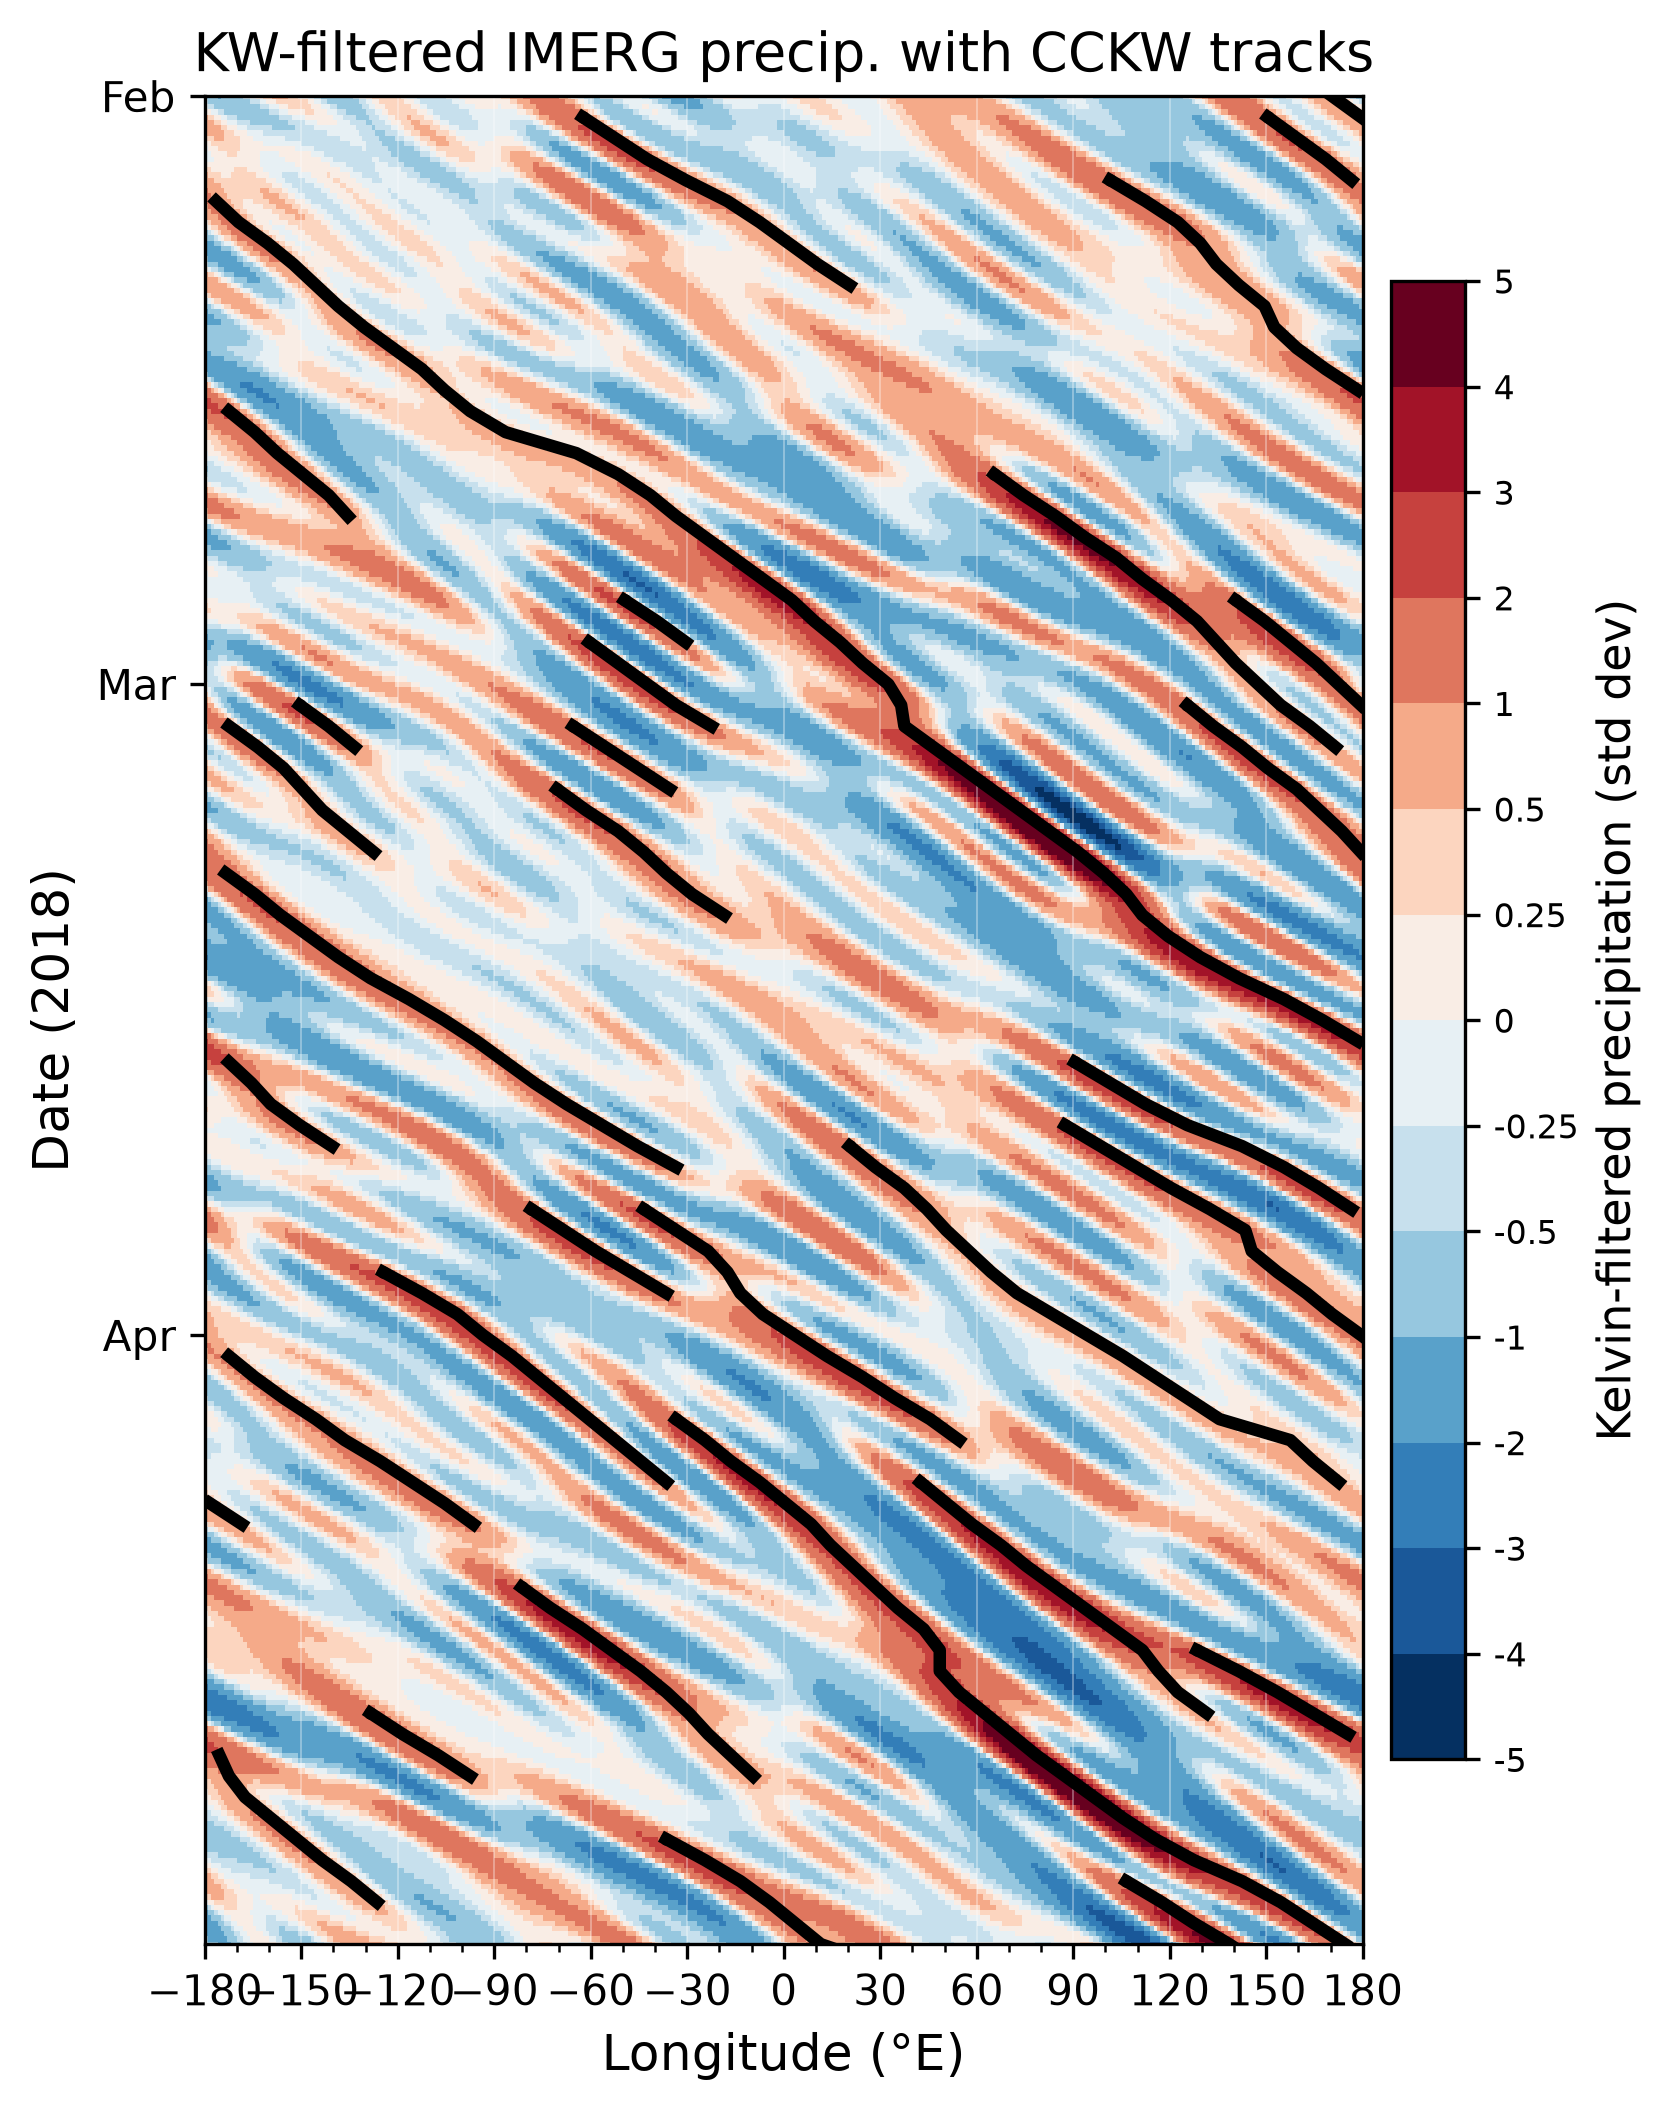

In [21]:
import matplotlib.colors as mcolors

# --- Prepare Hovmöller background ---
# Average filtered precip over 10S–10N and normalise to std devs
hov = filtered.sel(lat=slice(-10, 10)).mean(dim='lat')
std_val = float(hov.std())
hov_norm = hov / std_val if std_val > 0 else hov

# Convert lon from 0–360 to –180/+180 for a cleaner map
lon_vals = hov_norm.lon.values.copy()
lon_vals = (lon_vals + 180) % 360 - 180
hov_norm = hov_norm.assign_coords(lon=lon_vals).sortby('lon')

# --- Discrete colormap aligned to tracking thresholds ---
levels = [-5, -4, -3, -2, -1, -0.5, -0.25, 0, 0.25, 0.5, 1, 2, 3, 4, 5]
cmap = plt.cm.RdBu_r
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, clip=True)

# --- Build the plot ---
fig, ax = plt.subplots(figsize=(6, 8), dpi=300)

lons  = hov_norm.lon.values
times = hov_norm.time.values
data  = hov_norm.values

pm = ax.pcolormesh(lons, times, data, cmap=cmap, norm=norm, shading='auto')
cbar = plt.colorbar(pm, ax=ax, pad=0.02, shrink=0.8, ticks=levels)
cbar.set_label('Kelvin-filtered precipitation (std dev)', fontsize=11)
cbar.ax.set_yticklabels([f'{l:g}' for l in levels], fontsize=8)

# --- Overlay wave tracks ---
track_lons  = tracks['CCKW_lon'].values
track_times = tracks['CCKW_lon'].time.values

for sys_i in range(track_lons.shape[0]):
    row_lon  = track_lons[sys_i, :].copy()
    row_time = track_times.copy()

    valid = ~np.isnan(row_lon)
    if valid.sum() < 2:
        continue

    v_lon  = row_lon[valid]
    v_time = row_time[valid]

    # Break lines across the dateline
    lon_diffs   = np.abs(np.diff(v_lon))
    jump_indices = np.where(lon_diffs > 180)[0]
    v_lon  = np.insert(v_lon,  jump_indices + 1, np.nan)
    v_time = np.insert(v_time, jump_indices + 1, np.datetime64('NaT'))

    ax.plot(v_lon, v_time, color='black', linewidth=3, alpha=1)
    ax.plot(row_lon[valid][0], row_time[valid][0], 'k.', markersize=4)

# --- Formatting ---
ax.set_xlabel('Longitude (°E)', fontsize=12)
ax.set_ylabel('Date (2018)', fontsize=12)
ax.set_title('KW-filtered IMERG precip. with CCKW tracks', fontsize=13)
ax.set_xlim(-180, 180)
ax.set_ylim(np.datetime64(plot_date_start), np.datetime64(plot_date_end))
ax.set_xticks(np.arange(-180, 181, 30))
ax.xaxis.set_minor_locator(plt.MultipleLocator(10))
ax.yaxis.set_major_locator(mdates.MonthLocator())
ax.yaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.invert_yaxis()
ax.grid(axis='x', color='white', linewidth=0.4, alpha=0.4)

plt.show()

## 5. Quick summary statistics

In [22]:
# Track duration and mean amplitude for each system
durations = []
mean_strs = []

for sys_i in range(tracks.sizes['system']):
    row = tracks.isel(system=sys_i)
    valid = ~np.isnan(row['CCKW_lon'].values)
    if valid.sum() == 0:
        continue
    durations.append(int(valid.sum()))
    mean_strs.append(float(row['CCKW_str'].values[valid].mean()))

durations = np.array(durations)
mean_strs = np.array(mean_strs)

print(f'Number of CCKW tracks:       {len(durations)}')
print(f'Median duration:             {np.median(durations):.0f} days')
print(f'Longest track:               {durations.max()} days')
print(f'Mean normalised amplitude:   {mean_strs.mean():.2f} std devs')
print(f'Max normalised amplitude:    {mean_strs.max():.2f} std devs')

Number of CCKW tracks:       88
Median duration:             10 days
Longest track:               50 days
Mean normalised amplitude:   nan std devs
Max normalised amplitude:    nan std devs


## Example with different initial threshold
Set the initial threshold to 0.5 std devs instead of the default 1.0 std devs. You can also change the day-length requirement to be shorter. This will result in more tracks being detected, including weaker systems. 

This can be useful for fully capturing the life cycle of a system. To reduce false positives, you can apply an additional filter that removes any CCEW that does not clear at least 1 standard deviation in their lifetime. An example of this workflow is provided below. 

In [32]:
tracks = ccew_track.track(filtered, wave='Kelvin', daily_mean=True, init_threshold = 0.5, day_cut = 1)
print(tracks)

n_tracks = int((~np.isnan(tracks['CCKW_lon'].values).all(axis=1)).sum())
print(f'\nTotal CCKW tracks found in 2018: {n_tracks}')

Running wave tracker...
Connecting fragmented tracks...
Removing short tracks...
Done. Found 187 tracks.
<xarray.Dataset> Size: 1MB
Dimensions:   (system: 187, time: 365)
Coordinates:
  * system    (system) int64 1kB 1 2 3 4 5 6 7 8 ... 181 182 183 184 185 186 187
  * time      (time) datetime64[ns] 3kB 2018-01-01 2018-01-02 ... 2018-12-31
Data variables:
    CCKW_lon  (system, time) float64 546kB 79.5 88.5 96.5 ... 44.5 55.5 68.5
    CCKW_str  (system, time) float64 546kB 1.64 1.684 1.595 ... 0.3554 0.3334

Total CCKW tracks found in 2018: 187


In [33]:
# Filter tracks to only keep systems that exceed at least 1.0 std dev in their lifetime
print(f'Tracks before filtering (max amplitude >= 1.0 std dev): {n_tracks}')
max_str = tracks['CCKW_str'].max(dim='time')
strong_systems = max_str >= 1.0

tracks_filtered = tracks.sel(system=tracks.system[strong_systems])

n_tracks_filtered = int((~np.isnan(tracks_filtered['CCKW_lon'].values).all(axis=1)).sum())
print(f'Tracks after filtering (max amplitude >= 1.0 std dev): {n_tracks_filtered}')
print(tracks_filtered)

Tracks before filtering (max amplitude >= 1.0 std dev): 187
Tracks after filtering (max amplitude >= 1.0 std dev): 79
<xarray.Dataset> Size: 465kB
Dimensions:   (system: 79, time: 365)
Coordinates:
  * system    (system) int64 632B 1 9 11 15 16 17 18 ... 172 175 177 179 181 184
  * time      (time) datetime64[ns] 3kB 2018-01-01 2018-01-02 ... 2018-12-31
Data variables:
    CCKW_lon  (system, time) float64 231kB 79.5 88.5 96.5 ... 158.5 165.5 173.5
    CCKW_str  (system, time) float64 231kB 1.64 1.684 1.595 ... 2.179 2.448


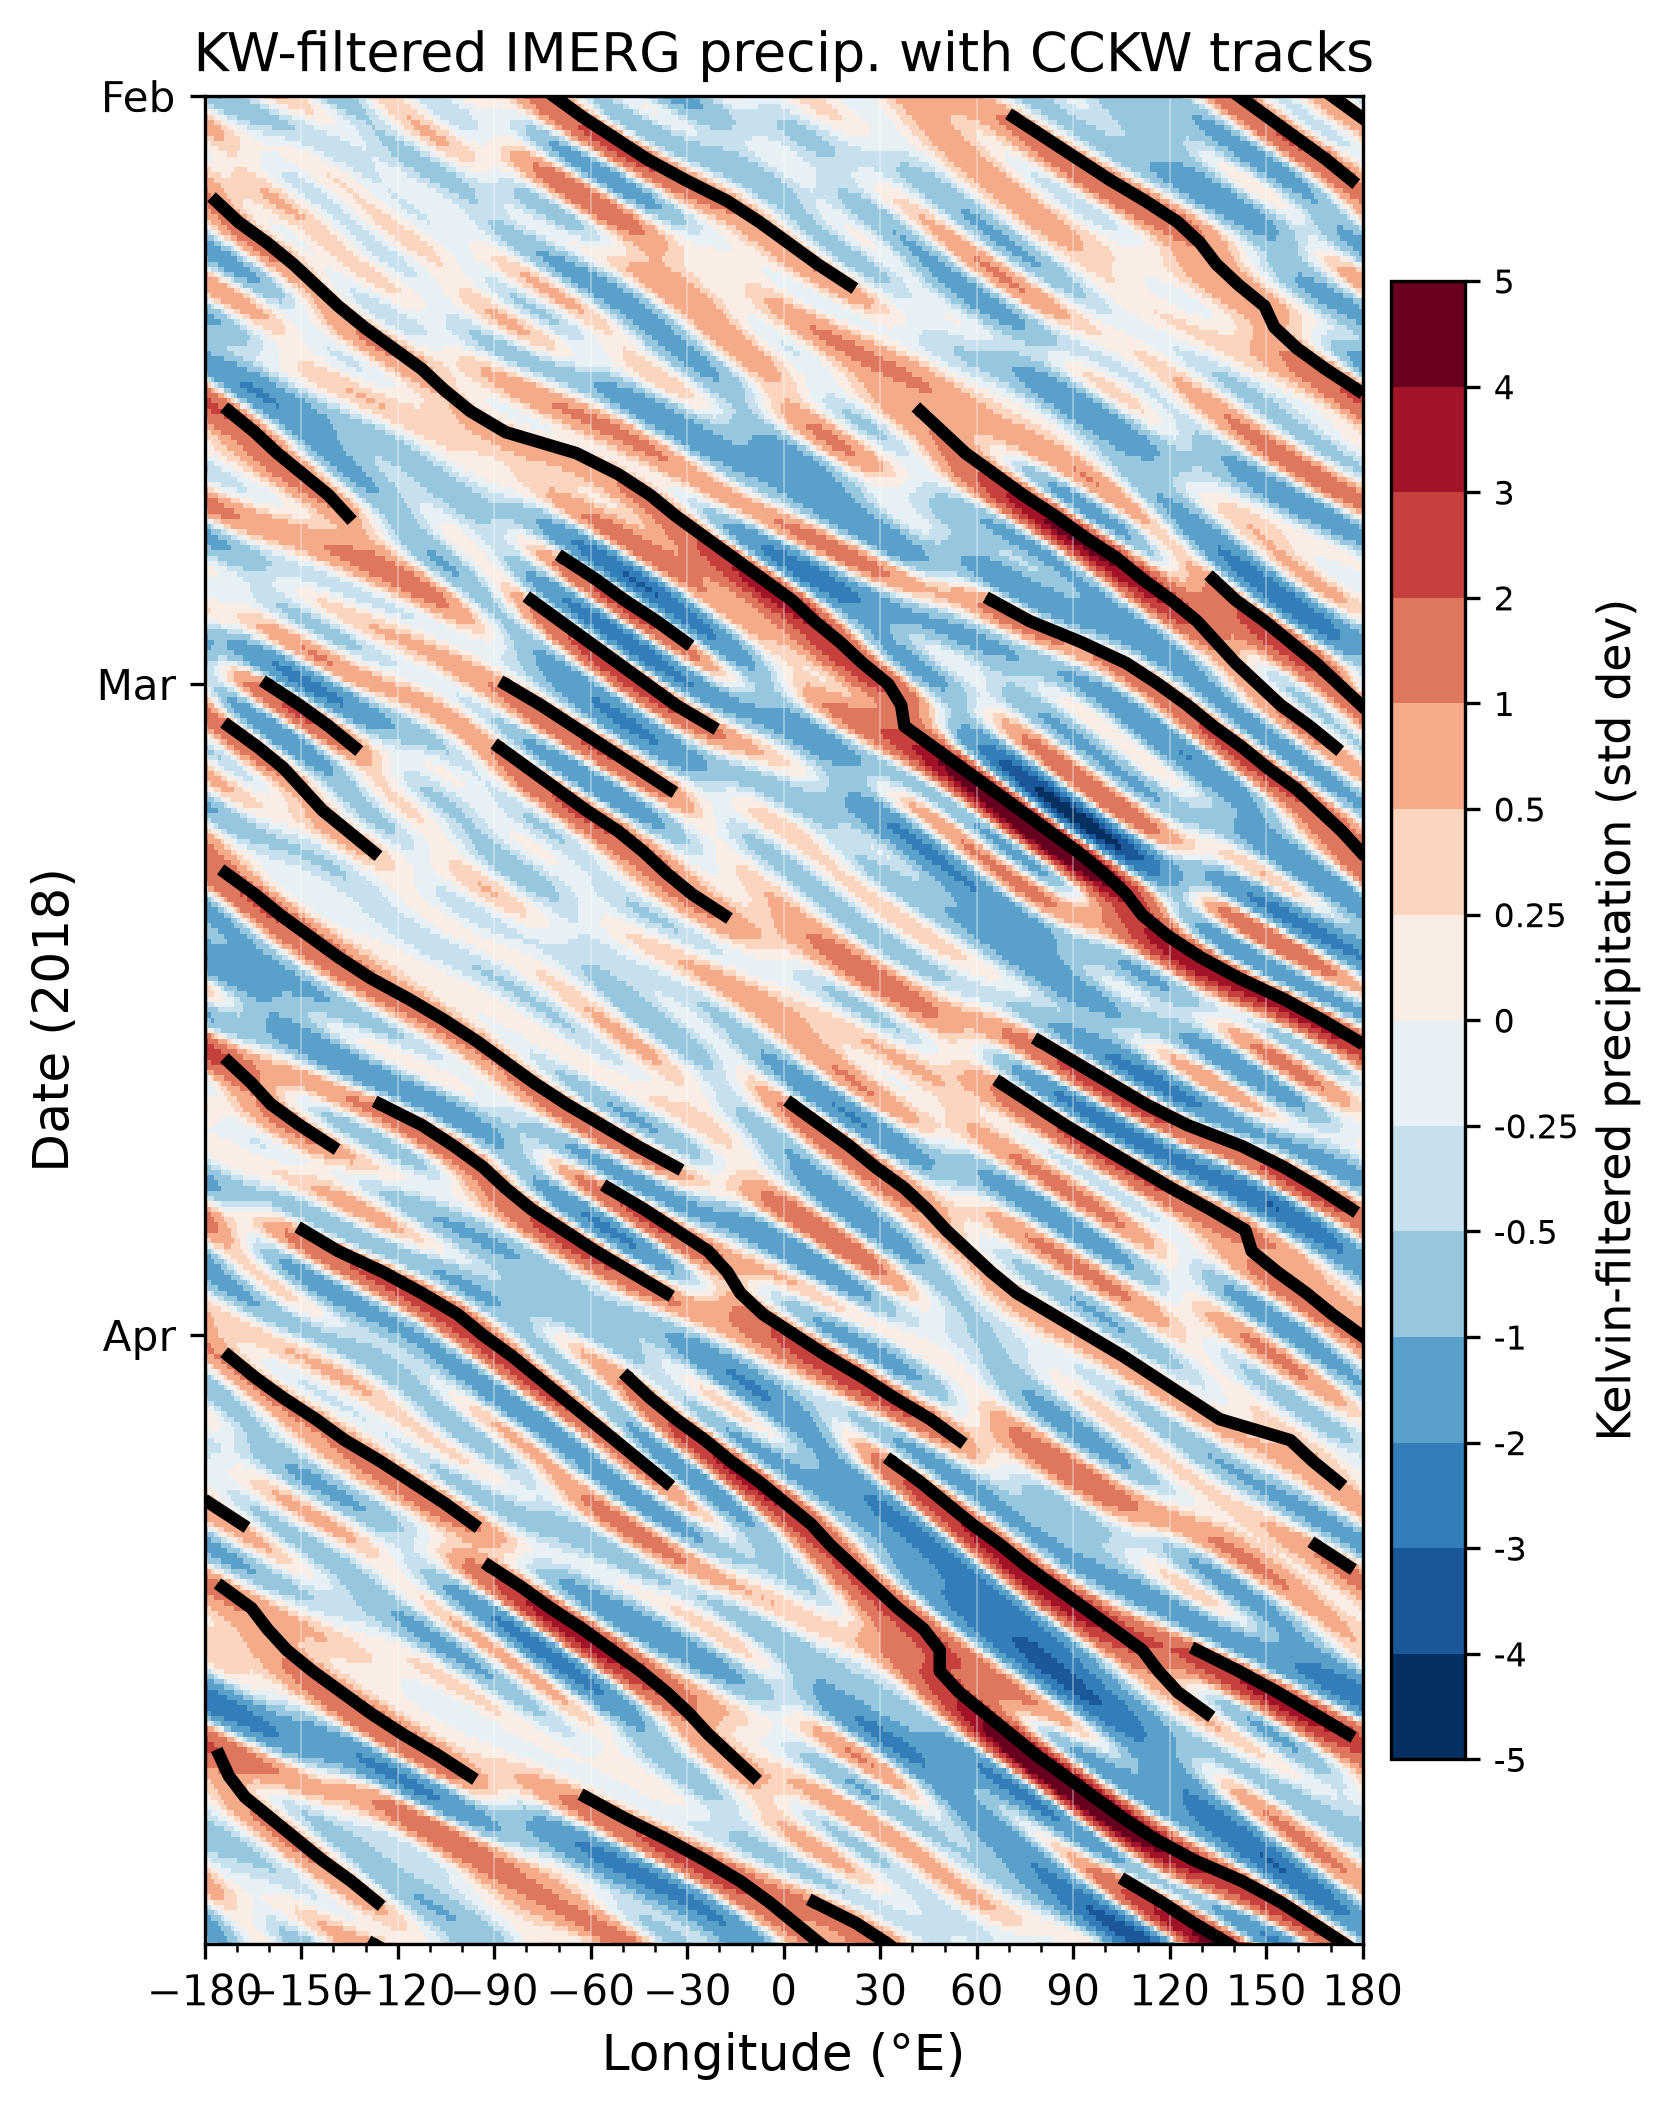

In [34]:
# --- Prepare Hovmöller background ---
# Average filtered precip over 10S–10N and normalise to std devs
hov = filtered.sel(lat=slice(-10, 10)).mean(dim='lat')
std_val = float(hov.std())
hov_norm = hov / std_val if std_val > 0 else hov

# Convert lon from 0–360 to –180/+180 for a cleaner map
lon_vals = hov_norm.lon.values.copy()
lon_vals = (lon_vals + 180) % 360 - 180
hov_norm = hov_norm.assign_coords(lon=lon_vals).sortby('lon')

# --- Discrete colormap aligned to tracking thresholds ---
levels = [-5, -4, -3, -2, -1, -0.5, -0.25, 0, 0.25, 0.5, 1, 2, 3, 4, 5]
cmap = plt.cm.RdBu_r
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, clip=True)

# --- Build the plot ---
fig, ax = plt.subplots(figsize=(6, 8), dpi=300)

lons  = hov_norm.lon.values
times = hov_norm.time.values
data  = hov_norm.values

pm = ax.pcolormesh(lons, times, data, cmap=cmap, norm=norm, shading='auto')
cbar = plt.colorbar(pm, ax=ax, pad=0.02, shrink=0.8, ticks=levels)
cbar.set_label('Kelvin-filtered precipitation (std dev)', fontsize=11)
cbar.ax.set_yticklabels([f'{l:g}' for l in levels], fontsize=8)

# --- Overlay wave tracks ---
track_lons  = tracks_filtered['CCKW_lon'].values
track_times = tracks_filtered['CCKW_lon'].time.values

for sys_i in range(track_lons.shape[0]):
    row_lon  = track_lons[sys_i, :].copy()
    row_time = track_times.copy()

    valid = ~np.isnan(row_lon)
    if valid.sum() < 2:
        continue

    v_lon  = row_lon[valid]
    v_time = row_time[valid]

    # Break lines across the dateline
    lon_diffs   = np.abs(np.diff(v_lon))
    jump_indices = np.where(lon_diffs > 180)[0]
    v_lon  = np.insert(v_lon,  jump_indices + 1, np.nan)
    v_time = np.insert(v_time, jump_indices + 1, np.datetime64('NaT'))

    ax.plot(v_lon, v_time, color='black', linewidth=3, alpha=1)
    ax.plot(row_lon[valid][0], row_time[valid][0], 'k.', markersize=4)

# --- Formatting ---
ax.set_xlabel('Longitude (°E)', fontsize=12)
ax.set_ylabel('Date (2018)', fontsize=12)
ax.set_title('KW-filtered IMERG precip. with CCKW tracks', fontsize=13)
ax.set_xlim(-180, 180)
ax.set_ylim(np.datetime64(plot_date_start), np.datetime64(plot_date_end))
ax.set_xticks(np.arange(-180, 181, 30))
ax.xaxis.set_minor_locator(plt.MultipleLocator(10))
ax.yaxis.set_major_locator(mdates.MonthLocator())
ax.yaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.invert_yaxis()
ax.grid(axis='x', color='white', linewidth=0.4, alpha=0.4)

plt.show()